# 01 — Data Audit
**Project:** HSR Decay in the UPL  
**Purpose:** Establish dataset completeness, distributions, and flag issues before any analysis  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ──────────────────────────────────────────────────────────────────
RAW_FILE = '../data/raw/24_25_season_raw_catapult_data.csv'  
MIN_HALF_DURATION_SECS = 2100                   # 35 minutes — substitution threshold
# ────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(RAW_FILE, low_memory=False)
print(f'Raw rows loaded: {len(df):,}')
print(f'Columns: {df.shape[1]}')

Raw rows loaded: 50,046
Columns: 100


## 1. Column Check

In [2]:
# Confirm the columns we need actually exist
required_cols = [
    'Session Title', 'Player Name', 'Split Name', 'Duration',
    'Distance in Speed Zone 4  (km)', 'Distance in Speed Zone 5  (km)',
    'Time in Speed Zone 4 (secs)', 'Time in Speed Zone 5 (secs)'
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    print('MISSING COLUMNS — fix before proceeding:')
    for c in missing:
        print(f'  - {c}')
else:
    print('All required columns present.')


All required columns present.


## 2. Split Name Values
We expect exactly three values: `all`, `1st.half`, `2nd.half`

In [3]:
print('Split Name value counts:')
print(df['Split Name'].value_counts())
print()

unexpected_splits = df[~df['Split Name'].isin(['all', '1st.half', '2nd.half'])]['Split Name'].unique()
if len(unexpected_splits) > 0:
    print('UNEXPECTED split values — investigate:')
    print(unexpected_splits)
else:
    print('Split values are clean.')

Split Name value counts:
Split Name
all                   15927
1st.half              10109
2nd.half              10109
Warm up                3391
Split 1                 985
                      ...  
pressing game 6 v        17
stretching (resist       17
Technique- acceler       15
SPEED ENDURANCE ON       14
Set Play                  1
Name: count, Length: 71, dtype: int64

UNEXPECTED split values — investigate:
<StringArray>
[           'Warm up',               'game',            'Split 1',
            'Split 2',            'Split 3',            'Split 4',
            'Split 5',    'Speed endurance',           'Pressing',
          'Defending', 'Stretching and wal', 'Warm down stretchi',
          'Set Plays',           'Set Play',           'training',
            'Agility', 'Reaction & Quick F', 'Technique - passin',
  'Tactical-pressing', 'Tactical -Shooting', 'Functional trainin',
 'Technique- acceler',     'Tactical Play ',     'Tactical- Game',
         'Stretching',      

## 3. Match Coverage

In [4]:
# Work on half splits only from here
halves = df[df['Split Name'].isin(['1st.half', '2nd.half'])].copy()

# Parse club and match day from Session Title
# Format: MD15-MAROONS FC-MBARARA FC-HOME-LEAGUE-DRAW
halves['match_id'] = halves['Session Title'].str.strip()

# Extract match day number
halves['match_day'] = halves['Session Title'].str.extract(r'MD(\d+)').astype(float)

# Extract outcome
halves['outcome_raw'] = halves['Session Title'].str.extract(r'-(WIN|LOSS|DRAW|LOSE)-?', expand=False)
# Standardise LOSE -> LOSS if needed
halves['outcome_raw'] = halves['outcome_raw'].str.replace('LOSE', 'LOSS')

# Extract home club (first club name after MD##-)
halves['home_club'] = halves['Session Title'].str.extract(r'MD\d+-([^-]+(?:-[^-]+)*?)-(?:[^-]+(?:-[^-]+)*?)-(?:HOME|AWAY)')

print(f'Total half-split rows: {len(halves):,}')
print(f'Unique match IDs: {halves["match_id"].nunique()}')
print(f'Match days found: {sorted(halves["match_day"].dropna().unique().astype(int).tolist())}')
print(f'\nOutcome distribution:')
print(halves.drop_duplicates("match_id")["outcome_raw"].value_counts())

Total half-split rows: 20,218
Unique match IDs: 683
Match days found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32]

Outcome distribution:
outcome_raw
WIN     102
DRAW     95
LOSS     75
Name: count, dtype: int64


## 4. Position Parsing

In [6]:
# Position is the last segment of Player Name: e.g. 'ROGERS KIWANUKA-MAROONS-RB'
halves['position_raw'] = halves['Player Name'].str.strip().str.split('-').str[-1].str.strip().str.upper()

print('All position tags found in data:')
print(halves['position_raw'].value_counts().to_string())

All position tags found in data:
position_raw
FW                2758
AM                2397
CB                2180
RB                1512
LB                1466
MF                1368
DM                1214
GK                1204
RW                1185
DF                1116
LW                1055
FWD                664
CM                 551
DC                 385
AMC                347
DMC                248
MC                 216
CD                 154
CF                  72
F                   36
MD                  36
LCB                 32
08                  10
CENTRE REFEREE       4
REFEREE              4
07                   2
CENTRE REFERE        2


In [10]:
# Map raw position tags to broad categories
# REVIEW THIS MAPPING — adjust based on what you see above
position_map = {
    # Goalkeepers
    'GK': 'GK',
    # Defenders
    'CB': 'DEF', 'RB': 'DEF', 'LB': 'DEF', 'DF': 'DEF', 'RWB': 'DEF', 'LWB': 'DEF',
    'SW': 'DEF', 'CD': 'DEF', 'LCB': 'DEF', 'RCB': 'DEF','DF': 'DEF','DC': 'DEF',
    # Midfielders
    'DM': 'MID', 'CM': 'MID', 'AM': 'MID', 'AMC': 'MID', 'DMC': 'MID','MD': 'MID',
    'RM': 'MID', 'LM': 'MID', 'MF': 'MID', 'CAM': 'MID', 'CDM': 'MID', 'MC': 'MID',
    # Forwards
    'ST': 'FWD', 'CF': 'FWD', 'LW': 'FWD', 'RW': 'FWD', 'SS': 'FWD',
    'FW': 'FWD', 'AM ': 'MID','F': 'FWD','FWD': 'FWD'
}

halves['position'] = halves['position_raw'].map(position_map)

unmapped = halves[halves['position'].isna()]['position_raw'].value_counts()
if len(unmapped) > 0:
    print('UNMAPPED positions — add to position_map above:')
    print(unmapped)
else:
    print('All positions mapped successfully.')

print('\nBroad position distribution (including GK):')
print(halves['position'].value_counts())

UNMAPPED positions — add to position_map above:
position_raw
08                10
CENTRE REFEREE     4
REFEREE            4
07                 2
CENTRE REFERE      2
Name: count, dtype: int64

Broad position distribution (including GK):
position
DEF    6845
MID    6377
FWD    5770
GK     1204
Name: count, dtype: int64


## 5. Duration Distribution

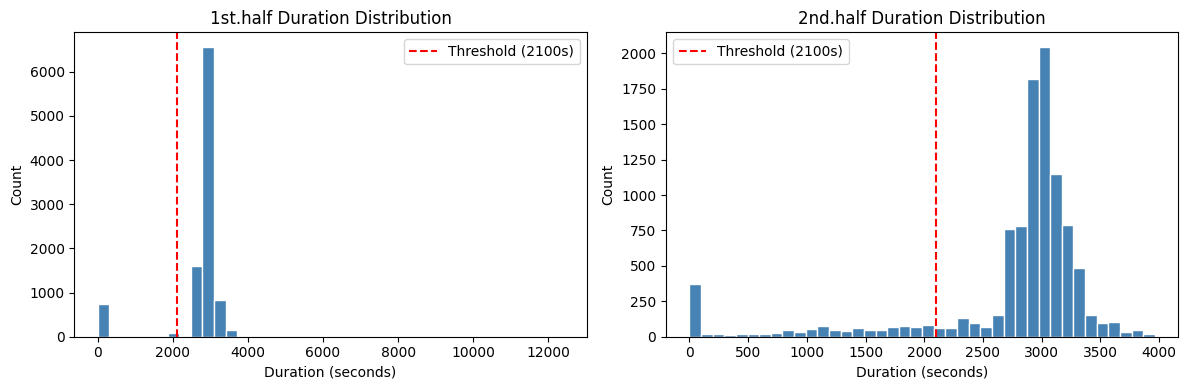

Duration stats by split:
              count    mean    std  min     25%     50%     75%      max
Split Name                                                              
1st.half    10109.0  2689.0  837.0  0.0  2788.0  2875.0  2963.0  12399.0
2nd.half    10109.0  2739.0  762.0  0.0  2767.0  2967.0  3095.0   3964.0


In [12]:
halves['Duration'] = pd.to_numeric(halves['Duration'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, split in zip(axes, ['1st.half', '2nd.half']):
    data = halves[halves['Split Name'] == split]['Duration']
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.axvline(MIN_HALF_DURATION_SECS, color='red', linestyle='--', label=f'Threshold ({MIN_HALF_DURATION_SECS}s)')
    ax.set_title(f'{split} Duration Distribution')
    ax.set_xlabel('Duration (seconds)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('../output/figures/audit_duration_distribution.png', dpi=150)
plt.show()

print('Duration stats by split:')
print(halves.groupby('Split Name')['Duration'].describe().round(0))

## 6. HSR Rate Calculation and Outlier Check

In [13]:
sz4_col = 'Distance in Speed Zone 4  (km)'
sz5_col = 'Distance in Speed Zone 5  (km)'

halves[sz4_col] = pd.to_numeric(halves[sz4_col], errors='coerce')
halves[sz5_col] = pd.to_numeric(halves[sz5_col], errors='coerce')

halves['hsr_rate'] = ((halves[sz4_col] + halves[sz5_col]) * 1000) / (halves['Duration'] / 60)

print('HSR Rate stats by split:')
print(halves.groupby('Split Name')['hsr_rate'].describe().round(2))

# Flag physiologically implausible values (> 160 m/min in a full half is suspicious)
outliers = halves[halves['hsr_rate'] > 160]
print(f'\nRows with HSR rate > 160 m/min: {len(outliers)}')
if len(outliers) > 0:
    print(outliers[['Player Name', 'Split Name', 'Duration', sz4_col, sz5_col, 'hsr_rate']].to_string())

HSR Rate stats by split:
             count  mean   std  min   25%   50%    75%    max
Split Name                                                   
1st.half    9408.0  6.21  5.74  0.0  0.00  5.66  10.52  31.74
2nd.half    9794.0  5.90  5.10  0.0  1.35  5.27   9.01  93.87

Rows with HSR rate > 160 m/min: 0


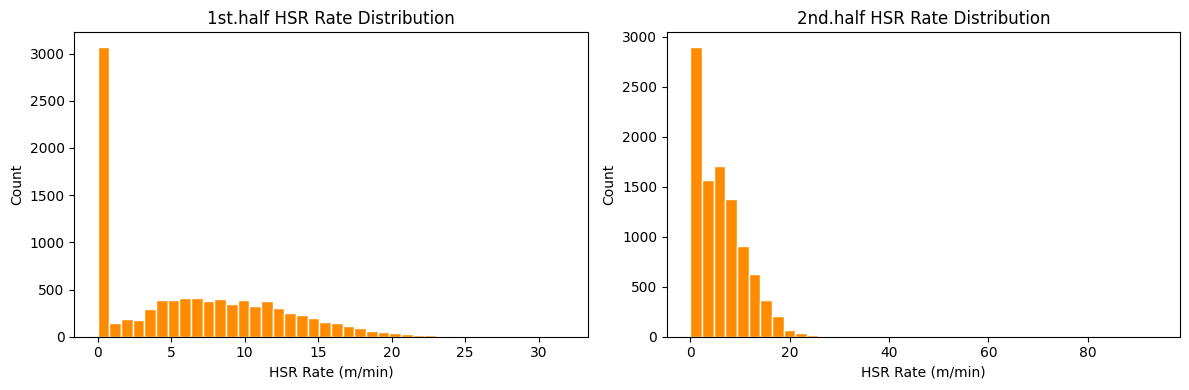

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, split in zip(axes, ['1st.half', '2nd.half']):
    data = halves[halves['Split Name'] == split]['hsr_rate'].dropna()
    ax.hist(data, bins=40, color='darkorange', edgecolor='white')
    ax.set_title(f'{split} HSR Rate Distribution')
    ax.set_xlabel('HSR Rate (m/min)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../output/figures/audit_hsr_distribution.png', dpi=150)
plt.show()

## 7. Paired Observation Check
How many player-match observations have BOTH halves present?

In [15]:
halves['player_match_id'] = halves['Player Name'].str.strip() + ' | ' + halves['match_id']

split_counts = halves.groupby('player_match_id')['Split Name'].nunique()
complete_pairs = (split_counts == 2).sum()
incomplete = (split_counts < 2).sum()

print(f'Player-match observations with both halves: {complete_pairs:,}')
print(f'Player-match observations with only one half: {incomplete:,}')
print(f'Completeness rate: {complete_pairs / (complete_pairs + incomplete):.1%}')

Player-match observations with both halves: 10,043
Player-match observations with only one half: 83
Completeness rate: 99.2%


## 8. Substitution Filter Preview
How many observations survive the 35-minute threshold?

In [16]:
outfield = halves[halves['position'] != 'GK'].copy()

above_threshold = outfield[outfield['Duration'] >= MIN_HALF_DURATION_SECS]
below_threshold = outfield[outfield['Duration'] < MIN_HALF_DURATION_SECS]

print(f'Outfield half-rows above threshold (>= {MIN_HALF_DURATION_SECS}s): {len(above_threshold):,}')
print(f'Outfield half-rows below threshold (excluded): {len(below_threshold):,}')
print(f'Retention rate: {len(above_threshold) / len(outfield):.1%}')

print('\nPosition breakdown after threshold filter:')
print(above_threshold.groupby(['position', 'Split Name']).size().unstack(fill_value=0))

Outfield half-rows above threshold (>= 2100s): 16,943
Outfield half-rows below threshold (excluded): 2,071
Retention rate: 89.1%

Position breakdown after threshold filter:
Split Name  1st.half  2nd.half
position                      
DEF             3230      3135
FWD             2579      2419
MID             2840      2718


## 9. Audit Summary

In [17]:
print('=' * 55)
print('DATA AUDIT SUMMARY')
print('=' * 55)
print(f'Raw rows:                     {len(df):>8,}')
print(f'Unique matches:               {halves["match_id"].nunique():>8,}')
print(f'Unique players:               {halves["Player Name"].nunique():>8,}')
print(f'Half-split rows:              {len(halves):>8,}')
print(f'Complete paired observations: {complete_pairs:>8,}')
print(f'Unmapped positions:           {halves["position"].isna().sum():>8,}')
print(f'HSR rate outliers (>160):     {len(outliers):>8,}')
print(f'Rows below duration threshold:{len(below_threshold):>8,}')
print('=' * 55)
print('\nIf unmapped positions > 0 or outliers look suspicious,')
print('resolve before moving to 02_cleaning.ipynb')

DATA AUDIT SUMMARY
Raw rows:                       50,046
Unique matches:                    683
Unique players:                    670
Half-split rows:                20,218
Complete paired observations:   10,043
Unmapped positions:                 22
HSR rate outliers (>160):            0
Rows below duration threshold:   2,071

If unmapped positions > 0 or outliers look suspicious,
resolve before moving to 02_cleaning.ipynb
